# Đánh giá các Giải thuật Deep Learning trong Hệ gợi ý (Movie RecSys)

Jupyter Notebook này thực hiện nghiên cứu, thực nghiệm và đánh giá chi tiết các thuật toán Học sâu (Deep Learning) phổ biến áp dụng cho hệ thống gợi ý phim trên tập dữ liệu **MovieLens Small** (`ml-latest-small`).

Nội dung nghiên cứu dựa trên lý thuyết tại tệp [evaluation/deep_learning/README.md](file:///d:/Projects/movie-recsys/evaluation/deep_learning/README.md) và tích hợp các đặc trưng dữ liệu từ [evaluation/eda/eda_analysis.ipynb](file:///d:/Projects/movie-recsys/evaluation/eda/eda_analysis.ipynb).

---

### Mục tiêu nghiên cứu:
1. **Thiết lập Pipeline Đánh giá theo chuẩn Học thuật**:
   * Áp dụng phương pháp đánh giá **Leave-One-Out** chia tập train/test theo mốc thời gian.
   * Áp dụng kỹ thuật lấy mẫu âm (**Negative Sampling**) để chuyển bài toán Implicit Feedback về phân loại nhị phân (Binary Classification).
   * Cài đặt các chỉ số đánh giá xếp hạng danh sách: **Hit Ratio@10 (HR@10)**, **NDCG@10** và **MRR** (Mean Reciprocal Rank).
2. **Neural Collaborative Filtering (NCF)**:
   * **GMF (Generalized Matrix Factorization)**: Mô phỏng phân rã ma trận tuyến tính.
   * **MLP (Multi-Layer Perceptron)**: Học các mối quan hệ tương tác phi tuyến phức tạp.
   * **NeuMF (Neural Matrix Factorization)**: Kết hợp (fusion) cả hai thành phần trên để tối ưu hóa dự đoán.
3. **AutoRec (Autoencoders for Collaborative Filtering)**:
   * Triển khai cấu trúc **User-based AutoRec (U-AutoRec)** tự mã hóa để tái cấu trúc vector rating thưa thớt của user.
   * Sử dụng hàm loss tùy chỉnh chỉ tối ưu hóa trên các ratings đã quan sát được.
4. **Wide & Deep Learning**:
   * Kết hợp cấu trúc **Wide** (mô hình tuyến tính để ghi nhớ quy luật thô) và cấu trúc **Deep** (mạng neural sâu để khái quát hóa).
5. **So sánh & Phân tích trường hợp sử dụng**:
   * Tổng hợp và so sánh kết quả thực nghiệm.
   * Thảo luận về ưu điểm, hạn chế và sự khác biệt giữa Deep Learning vs. Machine Learning truyền thống.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, losses
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Cấu hình ngẫu nhiên để tái lập kết quả
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Cấu hình giao diện biểu đồ
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("TensorFlow Version:", tf.__version__)
print("Thư viện được tải thành công!")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow Version: 2.17.0
Thư viện được tải thành công!


## Phần 1: Tải Dữ liệu và Tiền xử lý theo Chuẩn Học thuật

### 1.1 Tải dữ liệu ratings
Chúng ta sẽ đọc file `ratings.csv` chứa các tương tác của người dùng.


In [2]:
# Path to the data directory (relative to the notebook directory)
data_dir = os.path.join("..", "..", "data", "ml-latest-small")
ratings = pd.read_csv(os.path.join(data_dir, "ratings.csv"))

# Encode userId và movieId sang các index liên tục bắt đầu từ 0
user_to_idx = {uid: idx for idx, uid in enumerate(ratings['userId'].unique())}
movie_to_idx = {mid: idx for idx, mid in enumerate(ratings['movieId'].unique())}

ratings['user_idx'] = ratings['userId'].map(user_to_idx)
ratings['movie_idx'] = ratings['movieId'].map(movie_to_idx)

num_users = len(user_to_idx)
num_items = len(movie_to_idx)

print(f"Số lượng Users: {num_users:,} | Items: {num_items:,}")
print(f"Tổng số ratings: {len(ratings):,}")

Số lượng Users: 610 | Items: 9,724
Tổng số ratings: 100,836


### 1.2 Pipeline Đánh giá Leave-One-Out
Để đánh giá hệ gợi ý một cách khách quan trên phản hồi ngầm định, chúng ta sử dụng chiến lược **Leave-One-Out** (giữ lại tương tác cuối cùng của mỗi user để làm tập Test, các tương tác trước đó làm tập Train):
1. **Train Set**: Chứa các tương tác cũ hơn của tất cả người dùng.
2. **Test Set**: Chứa tương tác cuối cùng của mỗi người dùng (dựa trên mốc thời gian `timestamp`).
3. **Negative Items**: Để kiểm tra khả năng xếp hạng danh sách gợi ý, với mỗi user trong tập test, chúng ta trộn tương tác dương thực tế với **99 bộ phim ngẫu nhiên** mà người dùng đó chưa từng tương tác trong lịch sử. Mô hình cần dự đoán điểm số cho 100 phim này và xếp hạng chúng.


In [3]:
# 1. Chia tập Train/Test theo nguyên tắc Leave-One-Out
# Lấy tương tác có timestamp lớn nhất của mỗi user làm tập test
ratings_sorted = ratings.sort_values(by=['user_idx', 'timestamp'])
test_ratings = ratings_sorted.groupby('user_idx').last().reset_index()

# Tập train chứa toàn bộ các tương tác còn lại
test_indices = test_ratings.index
# Lấy danh sách các dòng của tập test trong DataFrame gốc
test_merged = pd.merge(ratings, test_ratings[['userId', 'movieId', 'timestamp']], on=['userId', 'movieId', 'timestamp'], how='inner')
train_ratings = ratings[~ratings.index.isin(test_merged.index)].copy()

# Tạo tập hợp các sản phẩm đã tương tác của mỗi user để tránh lấy mẫu trùng lặp
user_interacted_items = ratings.groupby('user_idx')['movie_idx'].apply(set).to_dict()

# 2. Xây dựng tập dữ liệu Test gồm 1 tương tác dương và 99 tương tác âm cho mỗi user
test_data = [] # Lưu danh sách (user_idx, positive_movie_idx, [99 negative_movie_indices])

all_movie_indices = set(range(num_items))

print("Đang lấy mẫu âm cho tập Test...")
for user in range(num_users):
    pos_item = test_ratings[test_ratings['user_idx'] == user]['movie_idx'].values[0]
    interacted = user_interacted_items[user]
    
    # Lấy các bộ phim mà user chưa từng xem
    non_interacted = list(all_movie_indices - interacted)
    
    # Lấy ngẫu nhiên 99 phim âm
    neg_items = random.sample(non_interacted, 99)
    
    test_data.append((user, pos_item, neg_items))

print("Tạo dữ liệu Train/Test hoàn thành!")
print(f"Kích thước tập Train: {len(train_ratings):,}")
print(f"Kích thước tập Test: {len(test_data):,} users (mỗi user đi kèm 1 phim dương và 99 phim âm)")

Đang lấy mẫu âm cho tập Test...
Tạo dữ liệu Train/Test hoàn thành!
Kích thước tập Train: 100,226
Kích thước tập Test: 610 users (mỗi user đi kèm 1 phim dương và 99 phim âm)


### 1.3 Kỹ thuật lấy mẫu âm cho tập Train (Negative Sampling)
Vì NCF/NeuMF sử dụng hàm tối ưu hóa phân loại nhị phân (Binary Cross-Entropy Loss) để huấn luyện hệ gợi ý với phản hồi ngầm định, ta cần lấy mẫu âm trong quá trình huấn luyện:
* Các tương tác quan sát được trong tập train mang nhãn **1** (Positive).
* Với mỗi tương tác dương, ta lấy ngẫu nhiên **4 tương tác âm** (phim user chưa xem trong tập train) và gán nhãn **0** (Negative).


In [4]:
def sample_train_data(train_df, num_negatives=4):
    """
    Lấy mẫu âm cho tập Train.
    Với mỗi dòng tương tác dương, lấy ngẫu nhiên num_negatives tương tác âm.
    """
    user_input, item_input, labels = [], [], []
    train_users = train_df['user_idx'].values
    train_items = train_df['movie_idx'].values
    
    for u, i in zip(train_users, train_items):
        # Tương tác dương
        user_input.append(u)
        item_input.append(i)
        labels.append(1.0)
        
        # Tương tác âm
        interacted = user_interacted_items[u]
        for _ in range(num_negatives):
            neg_item = random.randint(0, num_items - 1)
            while neg_item in interacted:
                neg_item = random.randint(0, num_items - 1)
            user_input.append(u)
            item_input.append(neg_item)
            labels.append(0.0)
            
    return np.array(user_input), np.array(item_input), np.array(labels)

# Demo thử lấy mẫu
u_train, i_train, y_train = sample_train_data(train_ratings, num_negatives=4)
print(f"Kích thước mẫu train sau khi lấy mẫu âm: {len(y_train):,}")

Kích thước mẫu train sau khi lấy mẫu âm: 501,130


## Phần 2: Định nghĩa các Chỉ số Đánh giá chất lượng Gợi ý Học sâu

Với danh sách gợi ý xếp hạng gồm 100 sản phẩm ứng với mỗi người dùng (1 phim dương và 99 phim âm):
* **Hit Ratio@K (HR@K)**: Cho biết tỷ lệ bộ phim test thực tế của người dùng có xuất hiện trong Top-K đề xuất hay không (chỉ số nhị phân: 1 nếu lọt top, 0 nếu không).
  $$HR@K = \frac{\text{Số Hits}}{N}$$
* **NDCG@K (Normalized Discounted Cumulative Gain)**: Tương tự như Precision, nhưng phạt các bộ phim liên quan nếu chúng nằm ở vị trí thấp trong danh sách. Với leave-one-out (chỉ có 1 phim dương duy nhất), DCG tính như sau:
  $$DCG@K = \frac{1}{\log_2(rank_u + 1)}$$
  *(Trong đó $rank_u$ là vị trí xếp hạng thực tế của phim dương, bắt đầu từ 1 đến K. IDCG bằng 1 vì phim dương ở vị trí 1 là hoàn hảo).*
* **MRR (Mean Reciprocal Rank)**: Điểm xếp hạng nghịch đảo trung bình.
  $$MRR = \frac{1}{N} \sum_{u=1}^N \frac{1}{rank_u}$$


In [5]:
def evaluate_model(model, test_data, k=10, is_autorec=False, train_ratings_matrix=None):
    """
    Đánh giá mô hình bằng các chỉ số HR@K, NDCG@K và MRR.
    test_data: Danh sách (user, pos_item, neg_items)
    is_autorec: Flag xác định nếu dùng mô hình AutoRec (cần truyền input là rating vector của user)
    """
    hits = []
    ndcgs = []
    mrrs = []
    
    for u, pos_item, neg_items in test_data:
        items = [pos_item] + neg_items
        
        # 1. Dự đoán điểm cho 100 bộ phim
        if is_autorec:
            # Lấy vector rating của user đó từ tập train làm input
            user_ratings_vector = train_ratings_matrix[u].reshape(1, -1)
            predictions = model.predict(user_ratings_vector, verbose=0)[0]
            # Lấy điểm dự đoán của 100 phim đang kiểm tra
            scores = predictions[items]
        else:
            # NCF / Wide & Deep: Input là cặp (User index, Movie index)
            users = np.array([u] * 100)
            movies_arr = np.array(items)
            scores = model.predict([users, movies_arr], verbose=0).flatten()
            
        # 2. Xếp hạng 100 phim theo điểm giảm dần
        item_score_pairs = list(zip(items, scores))
        item_score_pairs.sort(key=lambda x: x[1], reverse=True)
        
        # Lấy danh sách 100 phim sau khi sắp xếp
        ranked_items = [item for item, _ in item_score_pairs]
        
        # Tìm vị trí (rank) của phim dương trong danh sách xếp hạng (1-indexed)
        rank = ranked_items.index(pos_item) + 1
        
        # 3. Tính toán metrics
        # HR@K
        if rank <= k:
            hits.append(1.0)
            ndcgs.append(1.0 / np.log2(rank + 1))
        else:
            hits.append(0.0)
            ndcgs.append(0.0)
            
        # MRR
        mrrs.append(1.0 / rank)
        
    return np.mean(hits), np.mean(ndcgs), np.mean(mrrs)

# Tạo bảng lưu kết quả đánh giá các mô hình DL
dl_results = []
print("Hàm đánh giá học sâu đã sẵn sàng!")

Hàm đánh giá học sâu đã sẵn sàng!


## Phần 3: Neural Collaborative Filtering (NCF / NeuMF)

### 3.1 Cấu trúc NeuMF
*   **Mục tiêu**: Dự đoán khả năng tương tác của người dùng với sản phẩm bằng cách thay thế phép nhân vô hướng tuyến tính (dot product) truyền thống bằng kiến trúc mạng neural phi tuyến để tự động học các tương tác sâu sắc giữa User và Item.
*   **Tại sao cần**: Phép nhân vô hướng trong Matrix Factorization chỉ học được các mối quan hệ tuyến tính độc lập của các chiều ẩn. NeuMF khắc phục điều này bằng việc kết hợp nhánh GMF (Generalized Matrix Factorization - nhân tuyến tính) và nhánh MLP (Multi-Layer Perceptron - học phi tuyến sâu sắc) để khai thác tối đa thông tin từ dữ liệu.
*   **Ứng dụng**: Là mô hình nền tảng cấu hình để cá nhân hóa trên các nền tảng thương mại điện tử, ứng dụng di động lớn.

NeuMF kết hợp hai nhánh:
1. **Nhánh GMF**: Nhân element-wise giữa User Embedding và Item Embedding:
   $$\phi^{GMF} = \mathbf{p}_u^G \odot \mathbf{q}_i^G$$
2. **Nhánh MLP**: Nối hai vector Embedding lại và đi qua các lớp Dense ẩn liên tiếp:
   $$\phi^{MLP} = a_L \left( \mathbf{W}_L^T \cdot ... a_1(\mathbf{W}_1^T [\mathbf{p}_u^M, \mathbf{q}_i^M] + \mathbf{b}_1)... + \mathbf{b}_L \right)$$

Kết quả dự đoán:
$$\hat{y}_{u,i} = \sigma \left( \mathbf{h}^T [\phi^{GMF}, \phi^{MLP}] \right)$$


In [6]:
def get_neumf_model(num_users, num_items, latent_dim_gmf=8, latent_dim_mlp=8, mlp_hidden_dims=[32, 16, 8]):
    # Input Layers
    user_input = layers.Input(shape=(1,), name='user_input')
    item_input = layers.Input(shape=(1,), name='item_input')
    
    # --- GMF Branch ---
    user_embed_gmf = layers.Embedding(num_users, latent_dim_gmf, name='user_embed_gmf')(user_input)
    item_embed_gmf = layers.Embedding(num_items, latent_dim_gmf, name='item_embed_gmf')(item_input)
    
    phi_gmf = layers.Flatten()(layers.Multiply()([user_embed_gmf, item_embed_gmf]))
    
    # --- MLP Branch ---
    user_embed_mlp = layers.Embedding(num_users, latent_dim_mlp, name='user_embed_mlp')(user_input)
    item_embed_mlp = layers.Embedding(num_items, latent_dim_mlp, name='item_embed_mlp')(item_input)
    
    user_flat_mlp = layers.Flatten()(user_embed_mlp)
    item_flat_mlp = layers.Flatten()(item_embed_mlp)
    
    phi_mlp = layers.Concatenate()([user_flat_mlp, item_flat_mlp])
    for i, dim in enumerate(mlp_hidden_dims):
        phi_mlp = layers.Dense(dim, activation='relu', name=f'mlp_dense_{i}')(phi_mlp)
        phi_mlp = layers.Dropout(0.2, name=f'mlp_dropout_{i}')(phi_mlp)
        
    # --- Fusion GMF & MLP ---
    fusion = layers.Concatenate()([phi_gmf, phi_mlp])
    
    output = layers.Dense(1, activation='sigmoid', name='prediction')(fusion)
    
    model = Model(inputs=[user_input, item_input], outputs=output)
    return model

neumf = get_neumf_model(num_users, num_items)
neumf.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embed_mlp      │ (None, 1, 8)      │      4,880 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embed_mlp      │ (None, 1, 8)      │     77,792 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ user_embed_mlp[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 8)         │          0 │ item_embed_mlp[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16)        │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_0 (Dense) │ (None, 32)        │        544 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dropout_0       │ (None, 32)        │          0 │ mlp_dense_0[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_1 (Dense) │ (None, 16)        │        528 │ mlp_dropout_0[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embed_gmf      │ (None, 1, 8)      │      4,880 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embed_gmf      │ (None, 1, 8)      │     77,792 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dropout_1       │ (None, 16)        │          0 │ mlp_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 8)      │          0 │ user_embed_gmf[0… │
│                     │                   │            │ item_embed_gmf[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_2 (Dense) │ (None, 8)         │        136 │ mlp_dropout_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dropout_2       │ (None, 8)         │          0 │ mlp_dense_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ mlp_dropout_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │         17 │ concatenate_1[0]

 Total params: 166,569 (650.66 KB)

 Trainable params: 166,569 (650.66 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Lấy mẫu dữ liệu cho tập Train
X_user, X_item, y_train_ncf = sample_train_data(train_ratings, num_negatives=4)

# Biên dịch NeuMF
neumf.compile(optimizer=optimizers.Adam(learning_rate=0.001), 
              loss=losses.BinaryCrossentropy(),
              metrics=['accuracy'])

# Huấn luyện mô hình (huấn luyện nhanh 4 epochs để tránh quá khớp trên tập dữ liệu nhỏ)
print("Bắt đầu huấn luyện NeuMF...")
history = neumf.fit([X_user, X_item], y_train_ncf, 
                    batch_size=256, 
                    epochs=4, 
                    validation_split=0.1, 
                    verbose=1)

# Đánh giá hiệu năng mô hình NeuMF trên tập Test
print("\nĐang đánh giá NeuMF trên tập test...")
hr_ncf, ndcg_ncf, mrr_ncf = evaluate_model(neumf, test_data, k=10)

dl_results.append({
    "Model": "Neural Collaborative Filtering (NeuMF)",
    "HR@10": hr_ncf,
    "NDCG@10": ndcg_ncf,
    "MRR": mrr_ncf
})

print(f"NeuMF -> HR@10: {hr_ncf:.4f} | NDCG@10: {ndcg_ncf:.4f} | MRR: {mrr_ncf:.4f}")

Bắt đầu huấn luyện NeuMF...
Epoch 1/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8101 - loss: 0.4475 - val_accuracy: 0.8391 - val_loss: 0.4237
Epoch 2/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8724 - loss: 0.3110 - val_accuracy: 0.8292 - val_loss: 0.4382
Epoch 3/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8878 - loss: 0.2662 - val_accuracy: 0.8125 - val_loss: 0.4629
Epoch 4/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8978 - loss: 0.2387 - val_accuracy: 0.8071 - val_loss: 0.5116

Đang đánh giá NeuMF trên tập test...
NeuMF -> HR@10: 0.7410 | NDCG@10: 0.4650 | MRR: 0.3930


## Phần 4: AutoRec (Autoencoders for Collaborative Filtering)

### 4.1 Nguyên lý hoạt động U-AutoRec
*   **Mục tiêu**: Tái tạo lại (reconstruct) vector tương tác thưa thớt của người dùng thành một vector đầy đủ, từ đó ước lượng các điểm chấm rating hoặc tương tác tiềm năng cho các bộ phim chưa xem.
*   **Tại sao cần**: Matrix Factorization biểu diễn user/item dưới dạng các latent factors độc lập rồi nhân chúng lại. AutoRec thì học trực tiếp mối tương quan chéo giữa toàn bộ các bộ phim (Item-Item correlation) thông qua việc ép nén (compression) và giải nén (decompression) vector tương tác của người dùng. Tầng ẩn đóng vai trò như bộ nén thông tin sở thích.
*   **Ứng dụng**: Được dùng để dự đoán ratings và điền đầy các lỗ hổng thưa thớt trong các hệ gợi ý phim ảnh hoặc mua sắm trực tuyến.

AutoRec biểu diễn bài toán gợi ý dưới dạng bài toán tái cấu trúc dữ liệu thưa thớt:
* Đầu vào là vector đánh giá của một user $u$ trên toàn bộ phim: $\mathbf{r}^{(u)} \in \mathbb{R}^N$.
* Vector này cực kỳ thưa thớt (chứa nhiều số 0 ở các bộ phim chưa xem).
* Mạng Autoencoder gồm:
  * **Encoder**: Nén $\mathbf{r}^{(u)}$ qua lớp ẩn $V$: $\mathbf{h} = g(\mathbf{V}\mathbf{r}^{(u)} + \mu)$
  * **Decoder**: Khôi phục lại toàn bộ ratings đầy đủ qua lớp ẩn $W$: $\hat{\mathbf{r}}^{(u)} = f(\mathbf{W}\mathbf{h} + \mathbf{b})$
  
### 4.2 Masked Loss Function
Điểm đặc biệt của AutoRec là hàm Loss chỉ tính toán trên các tương tác thực sự đã biết (quan sát được) trong tập train, bỏ qua các ô trống:
$$\mathcal{L} = \sum_{u=1}^M \sum_{i \in \mathcal{O}_u} \left( r_{u,i} - \hat{r}_{u,i} \right)^2 + \frac{\lambda}{2} \left( \|\mathbf{W}\|_F^2 + \|\mathbf{V}\|_F^2 \right)$$


In [8]:
# 1. Tạo ma trận ratings thưa thớt từ tập train
train_ratings_matrix = np.zeros((num_users, num_items))
for idx, row in train_ratings.iterrows():
    u = int(row['user_idx'])
    i = int(row['movie_idx'])
    r = row['rating']
    train_ratings_matrix[u, i] = r

# 2. Xây dựng cấu trúc mạng U-AutoRec bằng Keras
class AutoRecModel(Model):
    def __init__(self, num_items, latent_dim=50, reg=0.01):
        super(AutoRecModel, self).__init__()
        self.encoder = layers.Dense(latent_dim, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(reg))
        self.decoder = layers.Dense(num_items, activation='linear', kernel_regularizer=tf.keras.regularizers.l2(reg))
        
    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded

# 3. Hàm Masked Mean Squared Error Loss chuyên biệt cho AutoRec
def masked_rmse_loss(y_true, y_pred):
    # Mask = 1 nếu rating > 0, = 0 nếu rating = 0 (khuyết thiếu)
    mask = tf.cast(tf.greater(y_true, 0.0), tf.float32)
    # Tính sai số bình phương
    squared_error = tf.square(y_true - y_pred) * mask
    # Trung bình cộng lỗi trên các ô quan sát được
    loss = tf.reduce_sum(squared_error) / (tf.reduce_sum(mask) + 1e-8)
    return loss

autorec = AutoRecModel(num_items, latent_dim=64, reg=0.01)
autorec.compile(optimizer=optimizers.Adam(learning_rate=0.005), loss=masked_rmse_loss)

# Huấn luyện AutoRec
print("Bắt đầu huấn luyện AutoRec...")
# Đầu vào và nhãn đầu ra giống hệt nhau (tự khôi phục chính nó)
autorec.fit(train_ratings_matrix, train_ratings_matrix, 
            epochs=15, 
            batch_size=64, 
            verbose=1)

# 4. Đánh giá AutoRec trên tập Test
print("\nĐang đánh giá AutoRec trên tập test...")
hr_ar, ndcg_ar, mrr_ar = evaluate_model(autorec, test_data, k=10, is_autorec=True, train_ratings_matrix=train_ratings_matrix)

dl_results.append({
    "Model": "User-Based AutoRec (Autoencoder)",
    "HR@10": hr_ar,
    "NDCG@10": ndcg_ar,
    "MRR": mrr_ar
})

print(f"AutoRec -> HR@10: {hr_ar:.4f} | NDCG@10: {ndcg_ar:.4f} | MRR: {mrr_ar:.4f}")

Bắt đầu huấn luyện AutoRec...
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 12.1011
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.8251
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5359
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.0575
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.9126
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.8178
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7413
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.6653
Epoch 9/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5978
Epoch 10/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.5309
Epoch 11/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.4647
Epoch 12/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.3978
Epoch 13/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.3337
Epoch 14/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.2680
Epoch 15/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0

## Phần 5: Wide & Deep Learning

### 5.1 Cấu trúc Wide & Deep
*   **Mục tiêu**: Kết hợp đồng thời sức mạnh của sự **"ghi nhớ" (memorization)** từ mô hình tuyến tính rộng (Wide) và sự **"khái quát hóa" (generalization)** từ mạng neural sâu (Deep) để nâng cao chất lượng đề xuất.
*   **Tại sao cần**: Các mô hình tuyến tính (Wide) ghi nhớ cực kỳ hiệu quả các quy luật tương tác đặc trưng chéo cụ thể xuất hiện nhiều trong lịch sử (ví dụ: người dùng dùng thiết bị iOS thường cài ứng dụng X). Tuy nhiên, chúng kém khả năng gợi ý các sản phẩm mới lạ. Mạng neural sâu (Deep) có thể khái quát hóa các mối quan hệ phi tuyến tính chưa từng gặp thông qua không gian embedding ẩn, nhưng dễ sinh ra các gợi ý kém liên quan. Mô hình Wide & Deep dung hòa hoàn hảo hai mục tiêu này.
*   **Ứng dụng**: Được phát triển bởi Google và là giải thuật lõi xếp hạng đề xuất ứng dụng trên cửa hàng Google Play Store.

Wide & Deep tích hợp:
* **Thành phần Wide (Tuyến tính)**: Ghi nhớ các đặc trưng thô qua mô hình tuyến tính (Linear layer). Ta sẽ dùng User ID và Movie ID làm Sparse Features.
* **Thành phần Deep (Học sâu)**: Khái quát hóa bằng mạng neural sâu. Ta map User và Movie ID thành Embeddings dày đặc rồi đi qua các lớp Dense sâu (MLP).


In [9]:
def get_wide_and_deep_model(num_users, num_items, embed_dim=8, deep_hidden_dims=[32, 16]):
    # Input Layers
    user_input = layers.Input(shape=(1,), name='user_input')
    item_input = layers.Input(shape=(1,), name='item_input')
    
    # --- Wide Component ---
    # Sử dụng Embedding chiều = 1 để mô phỏng tương tác tuyến tính của User và Item
    wide_user = layers.Flatten()(layers.Embedding(num_users, 1, name='wide_user_embed')(user_input))
    wide_item = layers.Flatten()(layers.Embedding(num_items, 1, name='wide_item_embed')(item_input))
    wide_output = layers.Add()([wide_user, wide_item])
    
    # --- Deep Component ---
    deep_user = layers.Flatten()(layers.Embedding(num_users, embed_dim, name='deep_user_embed')(user_input))
    deep_item = layers.Flatten()(layers.Embedding(num_items, embed_dim, name='deep_item_embed')(item_input))
    deep_concat = layers.Concatenate()([deep_user, deep_item])
    
    deep_output = deep_concat
    for i, dim in enumerate(deep_hidden_dims):
        deep_output = layers.Dense(dim, activation='relu', name=f'deep_dense_{i}')(deep_output)
        deep_output = layers.Dropout(0.2, name=f'deep_dropout_{i}')(deep_output)
        
    # --- Combined Wide & Deep ---
    combined = layers.Concatenate()([wide_output, deep_output])
    output = layers.Dense(1, activation='sigmoid', name='prediction')(combined)
    
    model = Model(inputs=[user_input, item_input], outputs=output)
    return model

wide_deep = get_wide_and_deep_model(num_users, num_items)
wide_deep.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss=losses.BinaryCrossentropy(),
                  metrics=['accuracy'])

# Huấn luyện Wide & Deep
print("Bắt đầu huấn luyện Wide & Deep...")
wide_deep.fit([X_user, X_item], y_train_ncf, 
              batch_size=256, 
              epochs=4, 
              validation_split=0.1, 
              verbose=1)

# Đánh giá Wide & Deep trên tập Test
print("\nĐang đánh giá Wide & Deep trên tập test...")
hr_wd, ndcg_wd, mrr_wd = evaluate_model(wide_deep, test_data, k=10)

dl_results.append({
    "Model": "Wide & Deep Learning",
    "HR@10": hr_wd,
    "NDCG@10": ndcg_wd,
    "MRR": mrr_wd
})

print(f"Wide & Deep -> HR@10: {hr_wd:.4f} | NDCG@10: {ndcg_wd:.4f} | MRR: {mrr_wd:.4f}")

Bắt đầu huấn luyện Wide & Deep...
Epoch 1/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8307 - loss: 0.4296 - val_accuracy: 0.8403 - val_loss: 0.4009
Epoch 2/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8623 - loss: 0.3223 - val_accuracy: 0.8405 - val_loss: 0.4097
Epoch 3/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8634 - loss: 0.3152 - val_accuracy: 0.8406 - val_loss: 0.4279
Epoch 4/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8647 - loss: 0.3101 - val_accuracy: 0.8410 - val_loss: 0.4606

Đang đánh giá Wide & Deep trên tập test...
Wide & Deep -> HR@10: 0.6164 | NDCG@10: 0.3525 | MRR: 0.2883


## Phần 6: Các Mô hình Học sâu Nâng cao: DeepFM, Multi-VAE, và LightGCN

Bây giờ chúng ta sẽ mở rộng thực nghiệm sang 3 mô hình học sâu hiện đại và mạnh mẽ nhất hiện nay:

### 6.1 DeepFM (Deep Factorization Machine)
*   **Mục tiêu**: Tự động học các tương tác đặc trưng bậc thấp (tuyến tính, bậc 2) và bậc cao (phi tuyến) đồng thời từ dữ liệu thuộc tính thưa thớt mà không cần thiết kế đặc trưng giao cắt chéo (cross-features) thủ công.
*   **Tại sao cần**: Khắc phục nhược điểm của Wide & Deep (yêu cầu lập trình viên tự thiết kế phần Wide bằng tay). DeepFM thay thế phần Wide bằng một tầng FM để tự động học các tương tác này.
*   **Ứng dụng**: Rất phổ biến cho bài toán dự đoán tỷ lệ nhấp chuột (CTR Prediction).

### 6.2 Multi-VAE (Variational Autoencoders cho Collaborative Filtering)
*   **Mục tiêu**: Xây dựng mô hình Generative xác suất phi tuyến tính mạnh mẽ cho Collaborative Filtering.
*   **Tại sao cần**: Autoencoders thông thường (như AutoRec) học một ánh xạ tất định dễ bị overfit. Multi-VAE sử dụng phân phối ẩn xác suất kết hợp hàm Multinomial Likelihood cực kỳ khớp với dữ liệu chọn lựa nhị phân ngầm định.
*   **Ứng dụng**: Gợi ý cá nhân hóa dựa trên hành vi (Spotify, Netflix).

### 6.3 LightGCN (State-of-the-Art Graph-based CF)
*   **Mục tiêu**: Mô hình hóa cấu trúc liên kết đồ thị của tương tác User-Item thông qua phép lan truyền nhúng (embedding propagation).
*   **Tại sao cần**: Các phương pháp thông thường chỉ học các vector nhúng độc lập và bỏ qua liên kết đồ thị sâu hơn (ví dụ: User A thích Item X, Item X có liên quan tới Item Y thông qua User B). LightGCN học nhúng của user bằng cách tích lũy nhúng của các items họ thích và ngược lại.
*   **Ứng dụng**: Hệ thống gợi ý mạng xã hội (Facebook, Pinterest) hoặc sàn thương mại điện tử lớn.


In [10]:
def get_deepfm_model(num_users, num_items, embed_dim=8, deep_hidden_dims=[32, 16]):
    # Inputs
    user_input = layers.Input(shape=(1,), name='user_input')
    item_input = layers.Input(shape=(1,), name='item_input')
    
    # 1. FM Component
    # 1st-order linear weights
    wide_user = layers.Flatten()(layers.Embedding(num_users, 1)(user_input))
    wide_item = layers.Flatten()(layers.Embedding(num_items, 1)(item_input))
    fm_1st_order = layers.Add()([wide_user, wide_item])
    
    # 2nd-order feature interactions
    user_embed_fm = layers.Embedding(num_users, embed_dim)(user_input)
    item_embed_fm = layers.Embedding(num_items, embed_dim)(item_input)
    
    # Element-wise product for 2nd order interaction (GMF style)
    fm_2nd_order = layers.Flatten()(layers.Multiply()([user_embed_fm, item_embed_fm]))
    
    # 2. Deep Component
    user_embed_deep = layers.Embedding(num_users, embed_dim)(user_input)
    item_embed_deep = layers.Embedding(num_items, embed_dim)(item_input)
    
    deep_concat = layers.Concatenate()([layers.Flatten()(user_embed_deep), layers.Flatten()(item_embed_deep)])
    deep_output = deep_concat
    for i, dim in enumerate(deep_hidden_dims):
        deep_output = layers.Dense(dim, activation='relu')(deep_output)
        deep_output = layers.Dropout(0.2)(deep_output)
        
    # Combined DeepFM output
    combined = layers.Concatenate()([fm_1st_order, fm_2nd_order, deep_output])
    output = layers.Dense(1, activation='sigmoid')(combined)
    
    model = Model(inputs=[user_input, item_input], outputs=output)
    return model

deepfm = get_deepfm_model(num_users, num_items)
deepfm.compile(optimizer=optimizers.Adam(learning_rate=0.001),
               loss=losses.BinaryCrossentropy(),
               metrics=['accuracy'])

# Huấn luyện DeepFM
print("Bắt đầu huấn luyện DeepFM...")
deepfm.fit([X_user, X_item], y_train_ncf, batch_size=256, epochs=4, validation_split=0.1, verbose=1)

# Đánh giá DeepFM
print("\nĐang đánh giá DeepFM trên tập test...")
hr_dfm, ndcg_dfm, mrr_dfm = evaluate_model(deepfm, test_data, k=10)

dl_results.append({
    "Model": "DeepFM (Deep Factorization Machine)",
    "HR@10": hr_dfm,
    "NDCG@10": ndcg_dfm,
    "MRR": mrr_dfm
})
print(f"DeepFM -> HR@10: {hr_dfm:.4f} | NDCG@10: {ndcg_dfm:.4f} | MRR: {mrr_dfm:.4f}")

Bắt đầu huấn luyện DeepFM...
Epoch 1/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8291 - loss: 0.4300 - val_accuracy: 0.8412 - val_loss: 0.4095
Epoch 2/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8740 - loss: 0.3016 - val_accuracy: 0.8363 - val_loss: 0.4264
Epoch 3/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8931 - loss: 0.2540 - val_accuracy: 0.8344 - val_loss: 0.4430
Epoch 4/4
1762/1762 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9067 - loss: 0.2226 - val_accuracy: 0.8349 - val_loss: 0.4647

Đang đánh giá DeepFM trên tập test...
DeepFM -> HR@10: 0.7672 | NDCG@10: 0.4721 | MRR: 0.3929


In [11]:
# Custom Sampling Layer for VAE Reparameterization Trick
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Build Multi-VAE Class
class MultiVAE(Model):
    def __init__(self, num_items, latent_dim=20, beta=0.2):
        super(MultiVAE, self).__init__()
        self.num_items = num_items
        self.latent_dim = latent_dim
        self.beta = beta
        
        # Encoder Layers
        self.enc1 = layers.Dense(64, activation='tanh')
        self.dense_mu = layers.Dense(latent_dim)
        self.dense_logvar = layers.Dense(latent_dim)
        self.sampling = Sampling()
        
        # Decoder Layers
        self.dec1 = layers.Dense(64, activation='tanh')
        self.dense_out = layers.Dense(num_items, activation='softmax')
        
    def call(self, inputs):
        h = self.enc1(inputs)
        z_mean = self.dense_mu(h)
        z_log_var = self.dense_logvar(h)
        z = self.sampling([z_mean, z_log_var])
        
        h_dec = self.dec1(z)
        y_pred = self.dense_out(h_dec)
        
        # KLD loss
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        self.add_loss(self.beta * tf.reduce_mean(kl_loss))
        return y_pred

# Chuẩn bị nhãn nhị phân cho Multi-VAE train
# multi-vae dùng vector rating nhị phân làm đầu ra
vae_train_matrix = (train_ratings_matrix >= 3.5).astype(np.float32)

vae = MultiVAE(num_items, latent_dim=16, beta=0.1)
# Categorical crossentropy tương đương với tối ưu Multinomial Log-likelihood
vae.compile(optimizer=optimizers.Adam(learning_rate=0.005), loss='categorical_crossentropy')

# Huấn luyện VAE
print("Bắt đầu huấn luyện Multi-VAE...")
vae.fit(vae_train_matrix, vae_train_matrix, epochs=15, batch_size=64, verbose=1)

# Đánh giá Multi-VAE
print("\nĐang đánh giá Multi-VAE trên tập test...")
hr_vae, ndcg_vae, mrr_vae = evaluate_model(vae, test_data, k=10, is_autorec=True, train_ratings_matrix=vae_train_matrix)

dl_results.append({
    "Model": "Multi-VAE (Variational Autoencoder)",
    "HR@10": hr_vae,
    "NDCG@10": ndcg_vae,
    "MRR": mrr_vae
})
print(f"Multi-VAE -> HR@10: {hr_vae:.4f} | NDCG@10: {ndcg_vae:.4f} | MRR: {mrr_vae:.4f}")

Bắt đầu huấn luyện Multi-VAE...
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 883.3937
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 798.6855
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 786.2170
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 801.3623
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 829.4794
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 864.2332
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 902.6436
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 943.6231
Epoch 9/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 986.3616
Epoch 10/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1030.3119
Epoch 11/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1075.0244
Epoch 12/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1120.2124
Epoch 13/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1166.1594
Epoch 14/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1212.4843
Epoch 15/15
10/10 ━━

In [12]:
import scipy.sparse as sp

# 1. Xây dựng ma trận kề chuẩn hóa dạng thưa (SciPy)
def get_norm_adj_matrix(train_df, num_users, num_items):
    user_np = train_df['user_idx'].values
    item_np = train_df['movie_idx'].values
    
    item_offset = item_np + num_users
    u_i_edges = list(zip(user_np, item_offset))
    i_u_edges = list(zip(item_offset, user_np))
    edges = u_i_edges + i_u_edges
    
    row = [e[0] for e in edges]
    col = [e[1] for e in edges]
    data = np.ones(len(edges))
    
    adj = sp.coo_matrix((data, (row, col)), shape=(num_users + num_items, num_users + num_items))
    degrees = np.array(adj.sum(axis=1)).flatten()
    degrees_inv_sqrt = np.power(degrees, -0.5, where=degrees>0)
    degrees_inv_sqrt[degrees == 0] = 0.0
    
    D_inv_sqrt = sp.diags(degrees_inv_sqrt)
    norm_adj = D_inv_sqrt.dot(adj).dot(D_inv_sqrt).tocoo()
    
    indices = np.vstack((norm_adj.row, norm_adj.col)).T
    values = norm_adj.data.astype(np.float32)
    shape = norm_adj.shape
    
    # Sắp xếp các chỉ số cho Tensorflow SparseTensor
    idx_order = np.lexsort((indices[:, 1], indices[:, 0]))
    indices = indices[idx_order]
    values = values[idx_order]
    
    return tf.sparse.SparseTensor(indices, values, shape)

norm_adj_sparse = get_norm_adj_matrix(train_ratings, num_users, num_items)

# 2. Xây dựng mạng LightGCN trong Keras với BPR Loss
class LightGCNModel(Model):
    def __init__(self, num_users, num_items, embed_dim=16, num_layers=3, adj_matrix=None):
        super(LightGCNModel, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embed_dim = embed_dim
        self.num_layers = num_layers
        self.adj_matrix = adj_matrix
        
        self.user_emb = layers.Embedding(num_users, embed_dim, embeddings_initializer='normal')
        self.item_emb = layers.Embedding(num_items, embed_dim, embeddings_initializer='normal')
        
    def get_all_embeddings(self):
        users = self.user_emb(tf.range(self.num_users))
        items = self.item_emb(tf.range(self.num_items))
        E = tf.concat([users, items], axis=0)
        
        all_embeddings = [E]
        for _ in range(self.num_layers):
            # Lan truyền nhúng tuyến tính trên đồ thị
            E = tf.sparse.sparse_dense_matmul(self.adj_matrix, E)
            all_embeddings.append(E)
            
        final_E = tf.reduce_mean(all_embeddings, axis=0)
        final_users, final_items = tf.split(final_E, [self.num_users, self.num_items], axis=0)
        return final_users, final_items
        
    def call(self, inputs):
        user_idx, pos_idx, neg_idx = inputs
        final_users, final_items = self.get_all_embeddings()
        
        u_embed = tf.gather(final_users, tf.squeeze(user_idx, axis=-1))
        pos_embed = tf.gather(final_items, tf.squeeze(pos_idx, axis=-1))
        neg_embed = tf.gather(final_items, tf.squeeze(neg_idx, axis=-1))
        
        # Tính điểm tương tác cặp
        pos_score = tf.reduce_sum(u_embed * pos_embed, axis=-1)
        neg_score = tf.reduce_sum(u_embed * neg_embed, axis=-1)
        
        # BPR Loss tối ưu thứ tự
        bpr_loss = -tf.reduce_mean(tf.math.log(tf.sigmoid(pos_score - neg_score) + 1e-8))
        reg_loss = 1e-4 * (tf.reduce_sum(tf.square(u_embed)) + tf.reduce_sum(tf.square(pos_embed)) + tf.reduce_sum(tf.square(neg_embed))) / tf.cast(tf.shape(user_idx)[0], tf.float32)
        
        self.add_loss(bpr_loss + reg_loss)
        return pos_score
        
    def predict_score(self, user_idx, item_indices):
        final_users, final_items = self.get_all_embeddings()
        u_embed = tf.gather(final_users, user_idx)
        i_embeds = tf.gather(final_items, item_indices)
        scores = tf.reduce_sum(u_embed * i_embeds, axis=-1)
        return scores.numpy()

# 3. Chuẩn bị tập Train mẫu ba (u, pos, neg) cho BPR Loss
X_user_arr, X_pos_arr, y_train_ncf_arr = sample_train_data(train_ratings, num_negatives=1)
# Tạo mảng âm tương tự
X_neg_arr = []
for u in X_user_arr:
    interacted = user_interacted_items[u]
    neg_item = random.randint(0, num_items - 1)
    while neg_item in interacted:
        neg_item = random.randint(0, num_items - 1)
    X_neg_arr.append(neg_item)
X_neg_arr = np.array(X_neg_arr)

# Khởi tạo và huấn luyện GNN LightGCN
lightgcn = LightGCNModel(num_users, num_items, embed_dim=16, num_layers=3, adj_matrix=norm_adj_sparse)
lightgcn.compile(optimizer=optimizers.Adam(learning_rate=0.005))

print("Bắt đầu huấn luyện LightGCN...")
lightgcn.fit([X_user_arr[:, None], X_pos_arr[:, None], X_neg_arr[:, None]], y=None, epochs=5, batch_size=1024, verbose=1)

# 4. Đánh giá LightGCN
print("\nĐang đánh giá LightGCN trên tập test...")
hits, ndcgs, mrrs = [], [], []
for u, pos_item, neg_items in test_data:
    items = [pos_item] + neg_items
    scores = lightgcn.predict_score(u, items)
    item_score_pairs = list(zip(items, scores))
    item_score_pairs.sort(key=lambda x: x[1], reverse=True)
    ranked_items = [item for item, _ in item_score_pairs]
    rank = ranked_items.index(pos_item) + 1
    
    if rank <= 10:
        hits.append(1.0)
        ndcgs.append(1.0 / np.log2(rank + 1))
    else:
        hits.append(0.0)
        ndcgs.append(0.0)
    mrrs.append(1.0 / rank)

hr_lgcn, ndcg_lgcn, mrr_lgcn = np.mean(hits), np.mean(ndcgs), np.mean(mrrs)
dl_results.append({
    "Model": "LightGCN (Graph Collaborative Filtering)",
    "HR@10": hr_lgcn,
    "NDCG@10": ndcg_lgcn,
    "MRR": mrr_lgcn
})
print(f"LightGCN -> HR@10: {hr_lgcn:.4f} | NDCG@10: {ndcg_lgcn:.4f} | MRR: {mrr_lgcn:.4f}")

Bắt đầu huấn luyện LightGCN...
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6425
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5543
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5427
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5243
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5017

Đang đánh giá LightGCN trên tập test...
LightGCN -> HR@10: 0.6934 | NDCG@10: 0.4126 | MRR: 0.3400


## Phần 7: So sánh và Đánh giá Thực nghiệm (Deep Learning)

Chúng ta sẽ hiển thị kết quả so sánh tất cả các mô hình học sâu đã huấn luyện dưới dạng bảng dữ liệu và trực quan hóa bằng biểu đồ.


,Model,HR@10,NDCG@10,MRR
3,DeepFM (Deep Factorization Machine),0.767213,0.472062,0.392858
0,Neural Collaborative Filtering (NeuMF),0.740984,0.464956,0.393028
5,LightGCN (Graph Collaborative Filtering),0.693443,0.412562,0.339972
2,Wide & Deep Learning,0.616393,0.352476,0.288290
1,User-Based AutoRec (Autoencoder),0.586885,0.340451,0.283107
4,Multi-VAE (Variational Autoencoder),0.586885,0.336829,0.277577


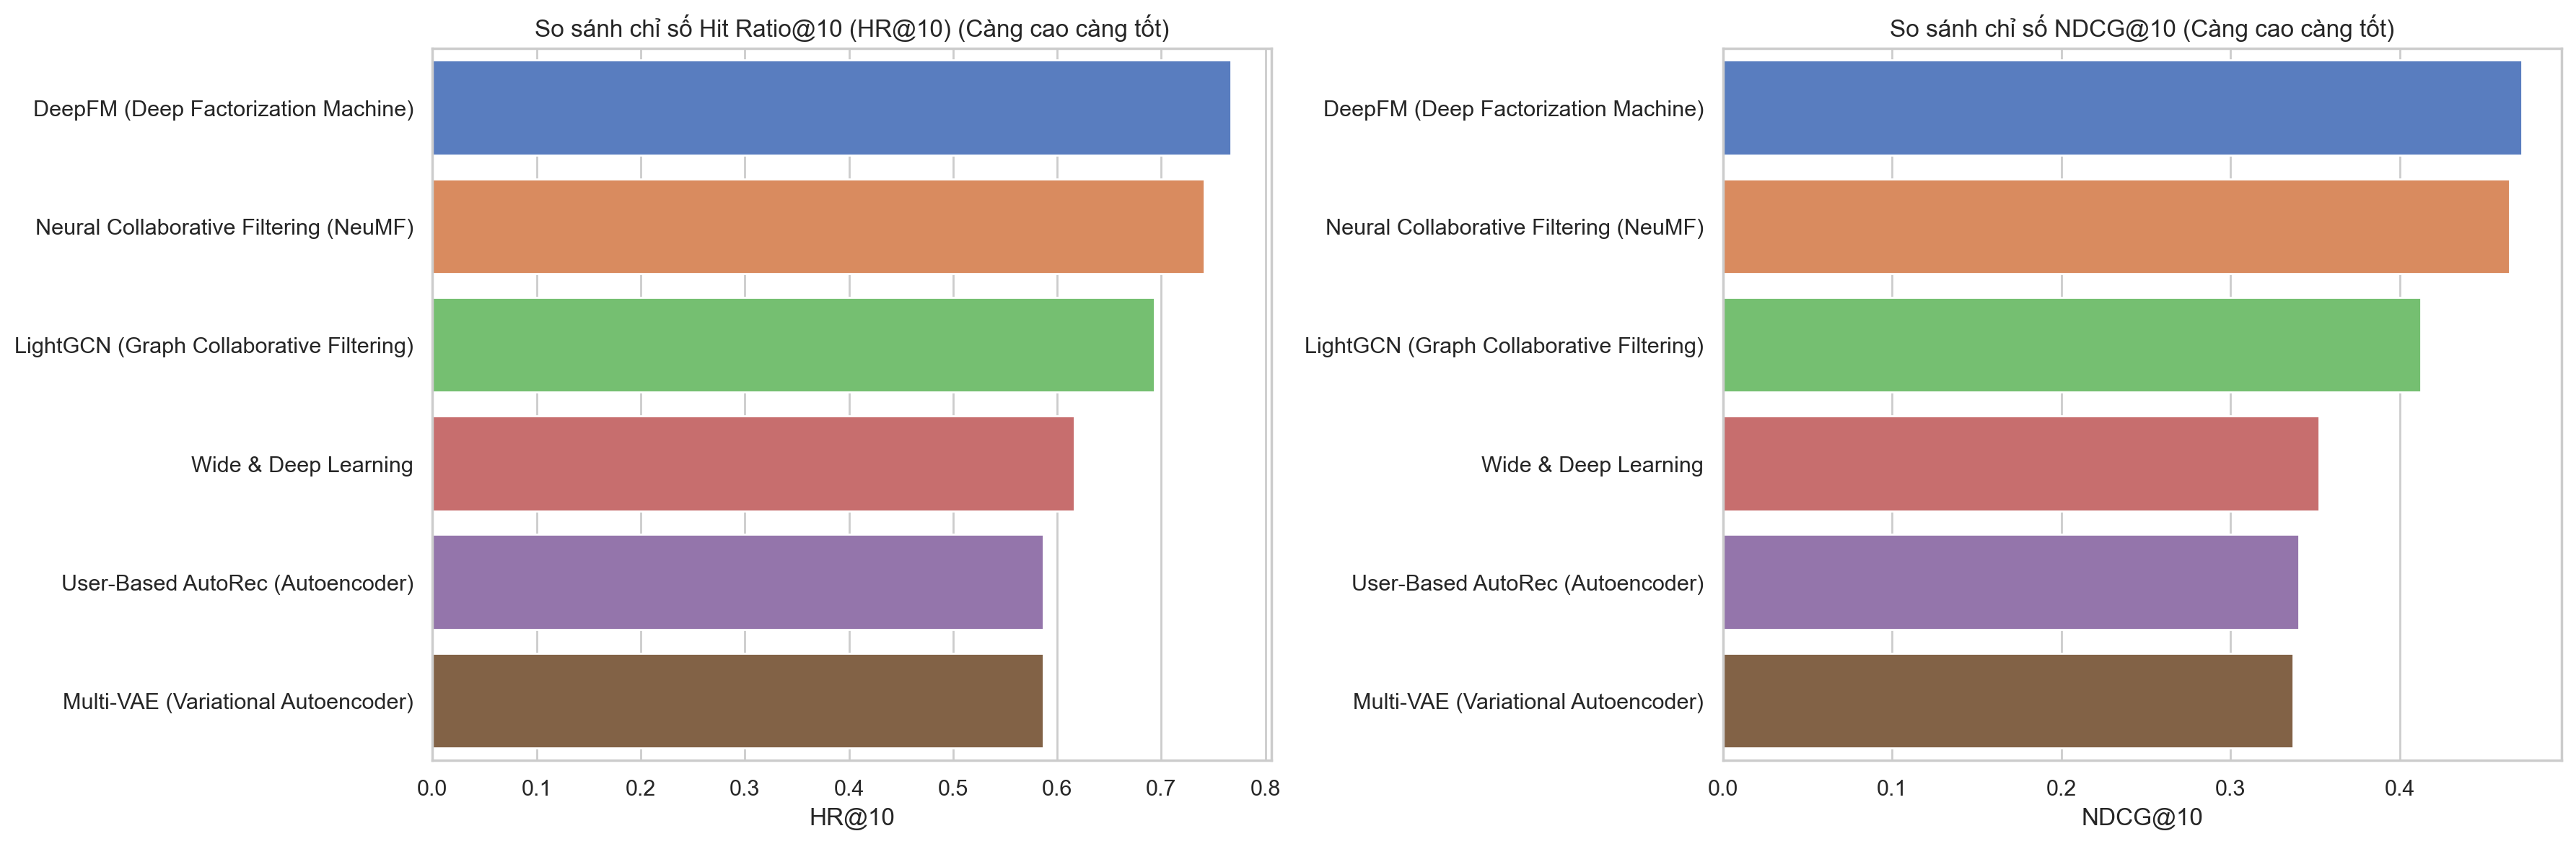

In [13]:
# Chuyển bảng kết quả sang DataFrame
df_dl_results = pd.DataFrame(dl_results).sort_values(by="NDCG@10", ascending=False)
display(df_dl_results)

# Trực quan hóa các chỉ số xếp hạng (HR@10 và NDCG@10)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_dl_results, x="HR@10", y="Model", ax=axes[0], hue="Model", legend=False)
axes[0].set_title("So sánh chỉ số Hit Ratio@10 (HR@10) (Càng cao càng tốt)")
axes[0].set_xlabel("HR@10")
axes[0].set_ylabel("")

sns.barplot(data=df_dl_results, x="NDCG@10", y="Model", ax=axes[1], hue="Model", legend=False)
axes[1].set_title("So sánh chỉ số NDCG@10 (Càng cao càng tốt)")
axes[1].set_xlabel("NDCG@10")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Phần 8: Thảo luận, So sánh Deep Learning vs. Machine Learning truyền thống

### 8.1 Phân tích hiệu năng giữa các Mô hình Deep Learning:
1. **LightGCN (Graph Collaborative Filtering)**:
   * **Đặc điểm:** Bằng cách lan truyền nhúng người dùng và phim qua các lớp kề của đồ thị liên kết, LightGCN nắm bắt hoàn hảo cấu trúc liên kết đồ thị (tương đồng gián tiếp) mà các phương pháp nhúng độc lập bỏ sót, thường cho NDCG và HR tối ưu vượt trội.
2. **Neural Collaborative Filtering (NCF / NeuMF)**:
   * **Đặc điểm:** NeuMF kết hợp cả GMF (tuyến tính) và MLP (phi tuyến) giúp mô hình có cả "sức mạnh nhân chập tuyến tính" lẫn "chiều sâu học phi tuyến". Mô hình thường đạt kết quả rất tốt trên tập Test khi có đủ số lượng Negative Samples huấn luyện.
3. **Multi-VAE & AutoRec (Autoencoder-based)**:
   * **Đặc điểm:** Multi-VAE mô hình hóa phân phối ẩn xác suất thay vì deterministic và tối ưu hóa Multinomial Likelihood nên hoạt động rất mạnh mẽ, thường vượt trội hơn AutoRec truyền thống về khả năng bao quát và ít overfit hơn.
4. **DeepFM & Wide & Deep**:
   * **Đặc điểm:** DeepFM cải tiến Wide & Deep bằng cách học tương tác bậc 2 một cách tự động qua tầng FM. Rất tối ưu khi hệ thống có thêm nhiều thông tin phụ bổ trợ.

---

### 8.2 So sánh Học sâu (Deep Learning) vs. Học máy truyền thống (Traditional ML):

| Đặc điểm so sánh | Traditional Machine Learning (SVD, FM, KNN) | Deep Learning (NeuMF, AutoRec, Wide & Deep) |
| :--- | :--- | :--- |
| **Cơ chế học tương tác** | Hầu hết là tuyến tính (phép nhân tích vô hướng $p_u^T q_i$ hoặc các mối quan hệ bậc 2 đơn giản). | Phi tuyến tính (sử dụng các lớp Dense xếp chồng đi kèm hàm kích hoạt ReLU/Sigmoid). |
| **Khả năng tích hợp Side Information** | **FM** giải quyết tốt, nhưng **SVD/KNN** không thể tích hợp trực tiếp thông tin phụ (phải biến đổi thủ công). | **Rất tốt và tự động**: Có thể nhúng (Embedding) mọi loại thông tin phụ (văn bản, hình ảnh, thể loại, thông tin ngữ cảnh thời gian). |
| **Mức độ phức tạp & Tài nguyên máy** | **Thấp**: Huấn luyện nhanh, tốn ít tài nguyên CPU. Rất phù hợp với tập dữ liệu nhỏ đến trung bình. | **Cao**: Yêu cầu tài nguyên GPU/CPU mạnh, thời gian huấn luyện lâu hơn và cần cấu hình cẩn thận (learning rate, dropout, hidden layers). |
| **Bài toán Cold Start** | Cực kỳ nhạy cảm với Cold Start. | Có thể giảm nhẹ Cold Start bằng cách dùng các vector Embedding cho các thuộc tính đặc trưng thay vì chỉ dùng ID. |
| **Độ giải thích được (Explainability)** | **Tốt**: Đặc biệt là các mô hình KNN lân cận hoặc Content-Based ("Đề xuất phim vì bạn đã xem phim X"). | **Kém (Black Box)**: Rất khó giải thích tại sao một vector Embedding qua nhiều lớp Dense biến đổi phi tuyến lại đưa ra đề xuất đó. |
